# 04 - Full Dataset Recall@K

Notebook này mở rộng đánh giá CLIP text-to-image retrieval từ subset lên toàn bộ dataset đã clean. Vì số query là toàn bộ caption của dataset, phần đánh giá dùng batched retrieval và không tạo similarity matrix cho tất cả captions cùng lúc.

## 1. Import libraries and define paths

In [6]:
import json
from pathlib import Path

import numpy as np
import torch
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor
import PIL.Image
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
METADATA_PATH = PROJECT_ROOT / "data/processed/metadata.json"

FULL_IMAGE_EMBEDDINGS_PATH = PROJECT_ROOT / "data/processed/clip_image_embeddings_full.npy"
FULL_METADATA_OUTPUT_PATH = PROJECT_ROOT / "data/processed/clip_full_metadata.json"
FULL_RECALL_RESULTS_PATH = PROJECT_ROOT / "data/processed/full_recall_results.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "openai/clip-vit-base-patch32"

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")

Project root: D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search
Device: cuda


## 2. Load full metadata

In [7]:
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print(f"Number of images: {len(metadata):,}")
print("Sample metadata[0]:")
print(metadata[0])

required_keys = {"image_id", "image_path", "captions"}
for idx, item in enumerate(metadata):
    missing_keys = required_keys - set(item.keys())
    if missing_keys:
        raise ValueError(f"Item {idx} is missing keys: {missing_keys}")
    if len(item["captions"]) != 5:
        raise ValueError(f"Item {idx} does not have exactly 5 captions")

first_image_path = PROJECT_ROOT / metadata[0]["image_path"]
print(f"First image exists: {first_image_path.exists()} - {first_image_path}")
if not first_image_path.exists():
    raise FileNotFoundError(first_image_path)

print("Metadata schema looks valid.")

Number of images: 31,782
Sample metadata[0]:
{'image_id': '1000092795.jpg', 'image_path': 'data/raw/Images/1000092795.jpg', 'captions': ['Two young guys with shaggy hair look at their hands while hanging out in the yard .', 'Two young , White males are outside near many bushes .', 'Two men in green shirts are standing in a yard .', 'A man in a blue shirt standing in a garden .', 'Two friends enjoy time spent together .']}
First image exists: True - D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\data\raw\Images\1000092795.jpg
Metadata schema looks valid.


## 3. Check all image files

In [8]:
missing_images = []

for item in tqdm(metadata, desc="Checking image files"):
    image_path = PROJECT_ROOT / item["image_path"]
    if not image_path.exists():
        missing_images.append(str(image_path))

if missing_images:
    print("Missing image files:")
    for path in missing_images[:10]:
        print(path)
    raise FileNotFoundError(f"Found {len(missing_images)} missing image files")

print("All image files exist.")

Checking image files: 100%|██████████| 31782/31782 [00:00<00:00, 125705.48it/s]

All image files exist.


## 4. Load CLIP model

In [9]:
model = CLIPModel.from_pretrained(MODEL_NAME)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

model = model.to(DEVICE)
model.eval()

print(f"Loaded model: {MODEL_NAME}")
print(f"Model device: {next(model.parameters()).device}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 52668.65it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model: openai/clip-vit-base-patch32
Model device: cuda:0


## 5. Encode full image embeddings

Nếu `clip_image_embeddings_full.npy` đã tồn tại, notebook sẽ load lại file này để tránh encode lại toàn bộ ảnh. Nếu file chưa tồn tại, notebook sẽ encode từ đầu và lưu embeddings vào `data/processed/clip_image_embeddings_full.npy`.

In [10]:
def get_feature_tensor(model_output):
    # Một số phiên bản transformers trả tensor trực tiếp, một số trả output object.
    if isinstance(model_output, torch.Tensor):
        return model_output
    if hasattr(model_output, "image_embeds") and model_output.image_embeds is not None:
        return model_output.image_embeds
    if hasattr(model_output, "text_embeds") and model_output.text_embeds is not None:
        return model_output.text_embeds
    if hasattr(model_output, "pooler_output") and model_output.pooler_output is not None:
        return model_output.pooler_output
    raise TypeError(f"Cannot extract feature tensor from output type: {type(model_output)}")


def encode_images(metadata_items, batch_size=64):
    all_embeddings = []

    for start in tqdm(range(0, len(metadata_items), batch_size), desc="Encoding images"):
        batch_items = metadata_items[start:start + batch_size]
        images = []

        for item in batch_items:
            image_path = PROJECT_ROOT / item["image_path"]
            image = PIL.Image.open(image_path).convert("RGB")
            images.append(image)

        inputs = processor(images=images, return_tensors="pt")
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

        with torch.no_grad():
            image_features = get_feature_tensor(model.get_image_features(**inputs))
            # Chuẩn hóa L2 để dùng cosine similarity qua inner product.
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        all_embeddings.append(image_features.cpu().numpy().astype(np.float32))

    return np.concatenate(all_embeddings, axis=0)


if FULL_IMAGE_EMBEDDINGS_PATH.exists():
    print(f"Loading existing image embeddings from: {FULL_IMAGE_EMBEDDINGS_PATH}")
    image_embeddings = np.load(FULL_IMAGE_EMBEDDINGS_PATH)
else:
    image_embeddings = encode_images(metadata, batch_size=64)
    np.save(FULL_IMAGE_EMBEDDINGS_PATH, image_embeddings)
    print(f"Saved image embeddings to: {FULL_IMAGE_EMBEDDINGS_PATH}")

with open(FULL_METADATA_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"image_embeddings.shape: {image_embeddings.shape}")
print(f"image_embeddings.dtype: {image_embeddings.dtype}")
print(f"Embeddings path: {FULL_IMAGE_EMBEDDINGS_PATH}")
print(f"Metadata output path: {FULL_METADATA_OUTPUT_PATH}")

Encoding images: 100%|██████████| 497/497 [05:14<00:00,  1.58it/s]


Saved image embeddings to: D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\data\processed\clip_image_embeddings_full.npy
image_embeddings.shape: (31782, 512)
image_embeddings.dtype: float32
Embeddings path: D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\data\processed\clip_image_embeddings_full.npy
Metadata output path: D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\data\processed\clip_full_metadata.json


## 6. Build all caption queries and ground-truth indices

In [11]:
captions = []
gt_indices = []

for image_index, item in enumerate(metadata):
    for caption in item["captions"]:
        captions.append(caption)
        gt_indices.append(image_index)

gt_indices = np.array(gt_indices, dtype=np.int64)

print(f"Number of images: {len(metadata):,}")
print(f"Number of captions/queries: {len(captions):,}")
print("Sample captions:")
for caption in captions[:5]:
    print(f"- {caption}")
print(f"Sample gt_indices: {gt_indices[:10]}")

Number of images: 31,782
Number of captions/queries: 158,910
Sample captions:
- Two young guys with shaggy hair look at their hands while hanging out in the yard .
- Two young , White males are outside near many bushes .
- Two men in green shirts are standing in a yard .
- A man in a blue shirt standing in a garden .
- Two friends enjoy time spent together .
Sample gt_indices: [0 0 0 0 0 1 1 1 1 1]


## 7. Batched Recall@K without full similarity matrix

Cell này chỉ tính similarity cho từng batch caption với toàn bộ image embeddings. Không tạo ma trận similarity `(num_captions, num_images)` cho toàn bộ captions cùng lúc.

In [12]:
def evaluate_recall_at_k_batched(
    captions,
    gt_indices,
    image_embeddings,
    batch_size=128,
    ks=(1, 5, 10),
):
    image_emb_tensor = torch.from_numpy(image_embeddings).float().to(DEVICE)
    max_k = max(ks)
    hit_counts = {k: 0 for k in ks}
    total = 0

    for start in tqdm(range(0, len(captions), batch_size), desc="Evaluating Recall@K"):
        end = min(start + batch_size, len(captions))
        batch_texts = captions[start:end]
        batch_gt = gt_indices[start:end]

        inputs = processor(
            text=batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
        )
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

        with torch.no_grad():
            text_features = get_feature_tensor(model.get_text_features(**inputs))
            # Chuẩn hóa text embeddings giống image embeddings.
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            scores = text_features @ image_emb_tensor.T
            topk_indices = torch.topk(scores, k=max_k, dim=1).indices.cpu().numpy()

        for k in ks:
            hits = np.any(topk_indices[:, :k] == batch_gt[:, None], axis=1)
            hit_counts[k] += hits.sum()

        total += len(batch_texts)

    return {
        "Recall@1": hit_counts[1] / total,
        "Recall@5": hit_counts[5] / total,
        "Recall@10": hit_counts[10] / total,
    }


recalls = evaluate_recall_at_k_batched(
    captions,
    gt_indices,
    image_embeddings,
    batch_size=128,
    ks=(1, 5, 10),
)

for metric_name, value in recalls.items():
    print(f"{metric_name}: {value * 100:.2f}%")

Evaluating Recall@K: 100%|██████████| 1242/1242 [01:15<00:00, 16.52it/s]

Recall@1: 21.60%
Recall@5: 41.32%
Recall@10: 50.81%


## 8. Analyze a few examples

In [13]:
def retrieve_top_k(query, image_embeddings, metadata, top_k=5):
    inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True,
        truncation=True,
    )
    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
    image_emb_tensor = torch.from_numpy(image_embeddings).float().to(DEVICE)

    with torch.no_grad():
        text_embedding = get_feature_tensor(model.get_text_features(**inputs))
        text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)
        scores = (text_embedding @ image_emb_tensor.T).squeeze(0)
        top_scores, top_indices = torch.topk(scores, k=top_k)

    results = []
    for rank, (score, image_index) in enumerate(zip(top_scores.cpu().numpy(), top_indices.cpu().numpy()), start=1):
        item = metadata[int(image_index)]
        results.append({
            "rank": rank,
            "image_id": item["image_id"],
            "image_path": item["image_path"],
            "score": float(score),
            "captions": item["captions"],
        })

    return results


def show_results(results):
    num_results = len(results)
    fig, axes = plt.subplots(1, num_results, figsize=(4 * num_results, 4))
    if num_results == 1:
        axes = [axes]

    for ax, result in zip(axes, results):
        image_path = PROJECT_ROOT / result["image_path"]
        image = PIL.Image.open(image_path).convert("RGB")
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(
            f"Rank {result['rank']} | {result['score']:.3f}\n{result['image_id']}",
            fontsize=10,
        )
        print(f"Rank {result['rank']} - {result['image_id']}: {result['captions'][0]}")

    plt.tight_layout()
    plt.show()


Query: a dog running on the grass
Rank 1 - 2982928615.jpg: The dog is running quickly through the meadow .
Rank 2 - 3597924257.jpg: A brown dog runs through a field of grass spotted with yellow flowers
Rank 3 - 3540416139.jpg: A golden dog is running across the grass chasing a white toy on the ground .
Rank 4 - 456512643.jpg: A tan dog is running fast through tall green grass .
Rank 5 - 2180480870.jpg: Tan dog running through long grass in a park-like setting .


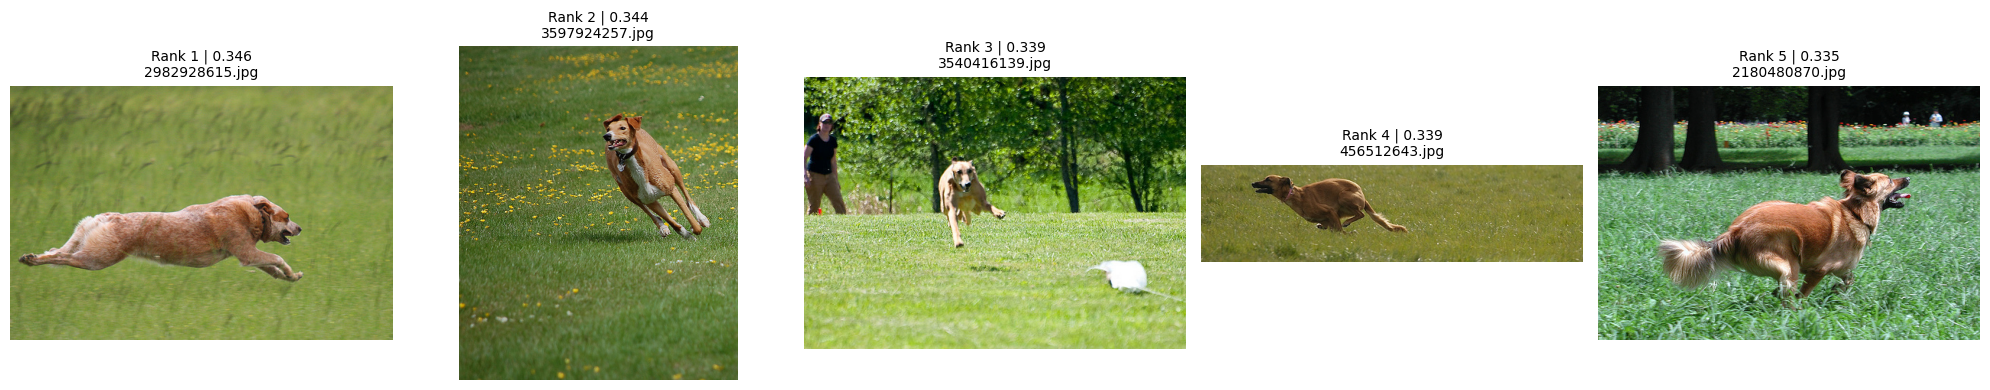


Query: a man riding a bicycle
Rank 1 - 4940921321.jpg: A man in dress clothes is riding a bike shielding his eyes from the sun .
Rank 2 - 4889818024.jpg: A man wearing a blue shirt and dark pants is riding a bicycle and is approaching an intersection .
Rank 3 - 2075321027.jpg: A man wearing a beret rides his bicycle on a recreation trail .
Rank 4 - 2137789511.jpg: An adult riding a bike on a beach with many visible vapour trails in the sky .
Rank 5 - 3182405529.jpg: an older man with long gray hair and a long gray beard bike riding on the shore .


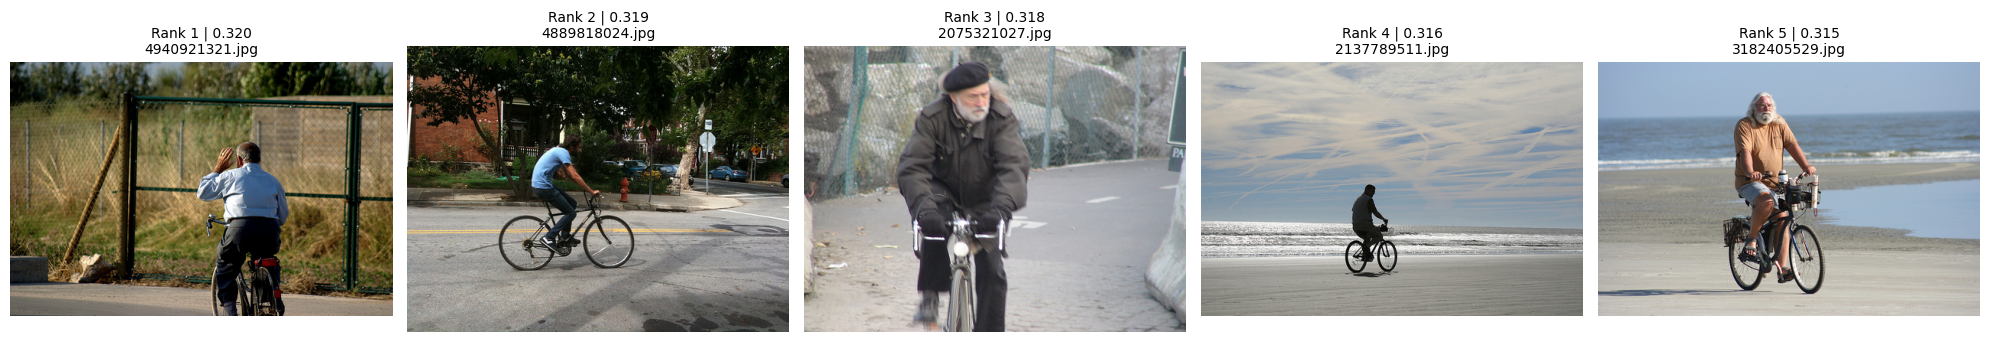


Query: children playing outside
Rank 1 - 2597958208.jpg: A little girl and boy play Frisbee together in a grassy area .
Rank 2 - 2772084628.jpg: four children are running up a path towards a red brick building .
Rank 3 - 125635185.jpg: Three children are playing outdoors , two of them on a metal barrel swing .
Rank 4 - 2499489346.jpg: A mother and three children play on a teeter totter at a playground .
Rank 5 - 1006452823.jpg: two children , a girl and a boy are practicing their writing .


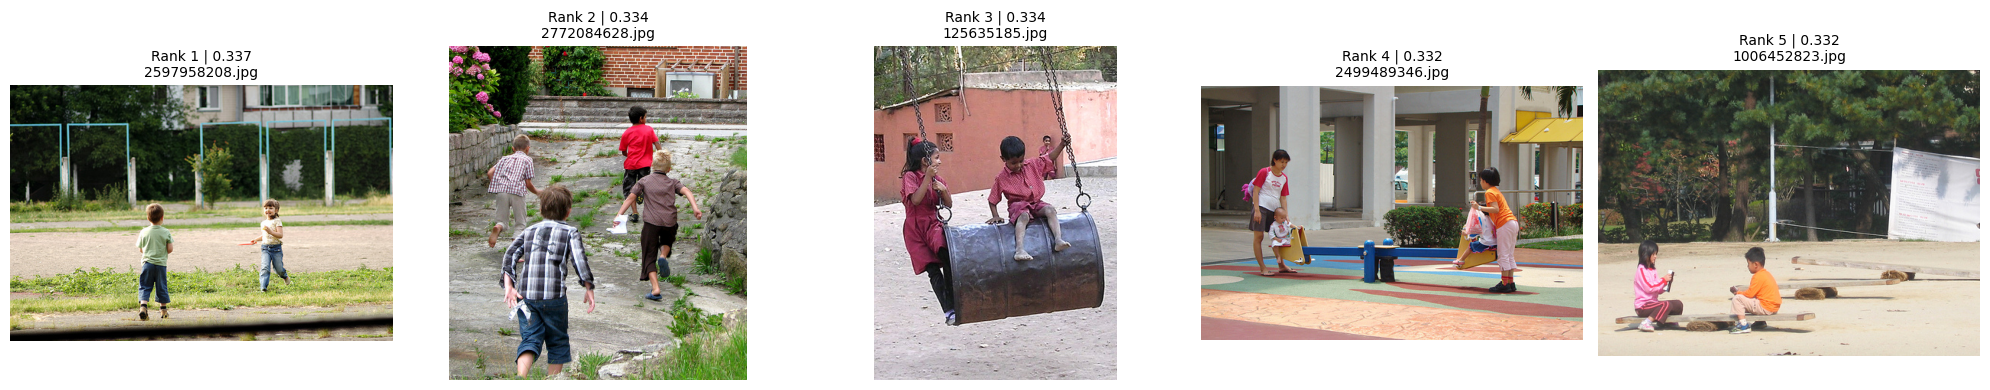


Query: a group of people sitting at a table
Rank 1 - 5301071699.jpg: A group of people , some with laptops , sit at several small tables with coffee mugs on them .
Rank 2 - 254478202.jpg: A blond woman in a sports jersey sits on a stool next to a table where several others have gathered .
Rank 3 - 686293997.jpg: A group of people sitting around a rectangular table having either pieces of paper or laptops in front of them .
Rank 4 - 3527682660.jpg: Three people sit in front of a man who is standing in front of a orange wall with art pictures on it .
Rank 5 - 1714937792.jpg: Four young men and three young women playing a card game at a table .


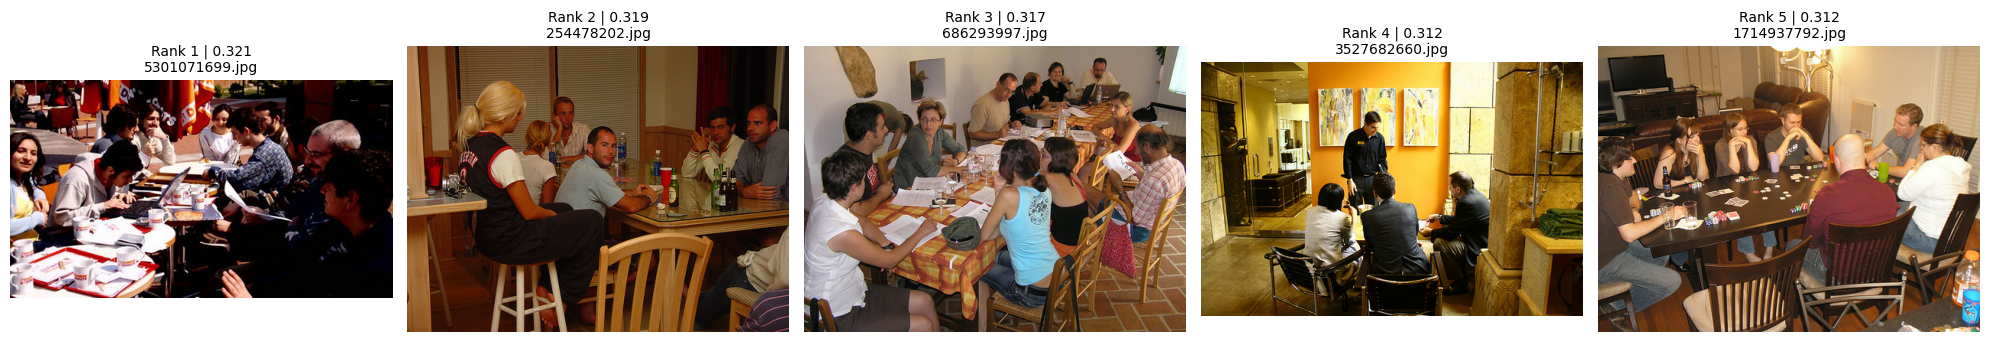

In [14]:
test_queries = [
    "a dog running on the grass",
    "a man riding a bicycle",
    "children playing outside",
    "a group of people sitting at a table",
]

for query in test_queries:
    print(f"\nQuery: {query}")
    results = retrieve_top_k(query, image_embeddings, metadata, top_k=5)
    show_results(results)

## 9. Save summary results

In [15]:
summary_results = {
    "model_name": MODEL_NAME,
    "num_images": len(metadata),
    "num_queries": len(captions),
    "recall": recalls,
}

with open(FULL_RECALL_RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(summary_results, f, indent=2, ensure_ascii=False)

print(f"Saved summary results to: {FULL_RECALL_RESULTS_PATH}")
print(json.dumps(summary_results, indent=2, ensure_ascii=False))

Saved summary results to: D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\data\processed\full_recall_results.json
{
  "model_name": "openai/clip-vit-base-patch32",
  "num_images": 31782,
  "num_queries": 158910,
  "recall": {
    "Recall@1": 0.21599647599270028,
    "Recall@5": 0.41317097728273866,
    "Recall@10": 0.5080737524384872
  }
}
